# Checkpoint 3 - Dataset and EDA for PickMeal ML

This notebook is the main file for **Checkpoint 3** in the ML part of the PickMeal project.

## Notebook goals
1. Fix the final list of data sources and their roles.
2. Run cleaning and EDA for the current menu datasets.
3. Create manifests and quarantine files.
4. Write clear conclusions for the README and report.
5. Fix the next baseline that should be built first.

## Final data decision
- **Roboflow Menu Text Box v3** - main supervised dataset for CV and layout.
- **Kaggle Indian Restaurant Menu Card Images** - auxiliary raw corpus for OCR checks and manual gold-set annotation.
- **USDA FoodData Central** - main nutrition knowledge base.
- **Open Food Facts** - additional open source food database for weak supervision and normalization.

## Files created by this notebook
- `data/interim/roboflow_manifest.csv`
- `data/interim/roboflow_boxes.csv`
- `data/interim/kaggle_manifest.csv`
- `data/interim/quarantine_empty_labels.csv`
- `data/interim/quarantine_corrupted_images.csv`
- `data/interim/quarantine_near_full_boxes.csv`
- `data/interim/dataset_summary.json`


In [ ]:
import json
from pathlib import Path

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image, UnidentifiedImageError

In [1]:
IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.webp', '.bmp', '.tif', '.tiff'}

project_root = Path('.').resolve()
if not (project_root / 'data').exists() and (project_root.parent / 'data').exists():
    project_root = project_root.parent

data_root = project_root / 'data'
interim_root = data_root / 'interim'
interim_root.mkdir(parents=True, exist_ok=True)

roboflow_root = data_root / 'raw' / 'roboflow_menu_text_box_v3' / 'Menu Text Box'
kaggle_root = data_root / 'raw' / 'kaggle_indian_menu_cards'

project_root: /Users/renataalieva/Desktop/MDS/pickmeal-ml
roboflow_root: /Users/renataalieva/Desktop/MDS/pickmeal-ml/data/raw/roboflow_menu_text_box_v3/Menu Text Box
kaggle_root: /Users/renataalieva/Desktop/MDS/pickmeal-ml/data/raw/kaggle_indian_menu_cards


## 1. Load config and helper functions

This part has simple helper code for:
- reading image files;
- reading YOLO labels;
- converting polygon labels to boxes;
- building a simple image hash for duplicate checks.


In [2]:
def iter_images(root):
    for path in root.rglob('*'):
        if path.is_file() and path.suffix.lower() in IMAGE_EXTS:
            yield path


def load_class_names(data_yaml_path):
    text = data_yaml_path.read_text(encoding='utf-8', errors='ignore')
    config = yaml.safe_load(text)
    names = config.get('names', [])

    if isinstance(names, dict):
        return [names[key] for key in sorted(names)]

    return list(names)


class_names = load_class_names(roboflow_root / 'data.yaml')


def simple_dhash(image_path, hash_size=8):
    try:
        with Image.open(image_path) as image:
            gray = image.convert('L').resize((hash_size + 1, hash_size), Image.Resampling.BILINEAR)
            arr = np.asarray(gray, dtype=np.uint8)

        diff = arr[:, 1:] > arr[:, :-1]
        bits = ''.join('1' if x else '0' for x in diff.flatten())
        return f"{int(bits, 2):0{hash_size * hash_size // 4}x}"
    except Exception:
        return None


def parse_yolo_or_polygon(label_path, class_names, split_name, image_path):
    text = label_path.read_text(encoding='utf-8', errors='ignore').strip()
    rows = []

    if text == '':
        return rows

    for line in text.splitlines():
        parts = line.strip().split()

        if len(parts) == 5:
            class_id = int(float(parts[0]))
            xc, yc, bw, bh = map(float, parts[1:])
            label_source = 'yolo'

        elif len(parts) > 5 and (len(parts) - 1) % 2 == 0:
            class_id = int(float(parts[0]))
            coords = list(map(float, parts[1:]))
            xs = coords[0::2]
            ys = coords[1::2]
            xmin = min(xs)
            xmax = max(xs)
            ymin = min(ys)
            ymax = max(ys)
            xc = (xmin + xmax) / 2
            yc = (ymin + ymax) / 2
            bw = xmax - xmin
            bh = ymax - ymin
            label_source = 'polygon_to_bbox'

        else:
            raise ValueError(f'Malformed label line in {label_path}: {line}')

        rows.append({
            'split': split_name,
            'image_path': image_path,
            'class_id': class_id,
            'class_name': class_names[class_id] if 0 <= class_id < len(class_names) else str(class_id),
            'xc': xc,
            'yc': yc,
            'bw': bw,
            'bh': bh,
            'annotation_source': label_source,
            'bbox_area_frac': bw * bh,
        })

    return rows


## 2. Build the Roboflow manifest

Here we create two tables:
- an image-level manifest;
- a box-level manifest.


In [3]:

rf_img_rows = []
rf_box_rows = []

for split in ("train", "valid", "test"):
    img_dir = roboflow_root / split / "images"
    lbl_dir = roboflow_root / split / "labels"
    lbl_map = {p.stem: p for p in lbl_dir.rglob("*.txt")}

    for img_path in sorted(iter_images(img_dir)):
        rel_img = str(img_path.relative_to(project_root))
        label_path = lbl_map.get(img_path.stem)
        rel_lbl = str(label_path.relative_to(project_root)) if label_path else None

        ok = 1
        err = ""
        width = height = None
        try:
            with Image.open(img_path) as im:
                width, height = im.size
        except Exception as e:
            ok = 0
            err = type(e).__name__

        label_bytes = label_path.stat().st_size if label_path and label_path.exists() else None
        min_side = min(width, height) if width is not None and height is not None else None

        rf_img_rows.append({
            "source": "roboflow",
            "split": split,
            "image_path": rel_img,
            "label_path": rel_lbl,
            "img_w": width,
            "img_h": height,
            "image_bytes": img_path.stat().st_size,
            "label_bytes": label_bytes,
            "ok": ok,
            "error_type": err,
            "is_tiny": int(min_side is not None and min_side < 150),
            "dhash": simple_dhash(img_path),
        })

        if ok and label_path and label_path.exists():
            rf_box_rows.extend(parse_yolo_or_polygon(label_path, class_names, split, rel_img))

images_rf = pd.DataFrame(rf_img_rows)
boxes_rf = pd.DataFrame(rf_box_rows)

print("images_rf:", len(images_rf))
print("boxes_rf:", len(boxes_rf))
display(images_rf.head(3))
display(boxes_rf.head(3))


images_rf: 4757
boxes_rf: 20217


,source,split,image_path,label_path,img_w,img_h,image_bytes,label_bytes,ok,error_type,is_tiny,dhash
0,roboflow,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,data/raw/roboflow_menu_text_box_v3/Menu Text B...,630,972,62054,156,1,,0,9e0e160e87878f84
1,roboflow,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,data/raw/roboflow_menu_text_box_v3/Menu Text B...,630,972,56798,155,1,,0,868e878f0e0e0ec6
2,roboflow,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,data/raw/roboflow_menu_text_box_v3/Menu Text B...,630,972,60510,157,1,,0,0e0e070f07070f86


,split,image_path,class_id,class_name,xc,yc,bw,bh,annotation_source,bbox_area_frac
0,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,0,menu-text,0.488889,0.472222,0.744444,0.931070,yolo,0.693130
1,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,0,menu-text,0.516667,0.960905,0.966667,0.078189,yolo,0.075583
2,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,0,menu-text,0.491270,0.472222,0.719048,0.923868,yolo,0.664305


## 3. Build the Kaggle manifest

We use this source as a raw domain corpus.
For this reason, the image-level manifest is enough:
- file validity;
- image size;
- aspect ratio;
- simple image hash.


In [4]:

kg_rows = []

for img_path in sorted(iter_images(kaggle_root)):
    rel_img = str(img_path.relative_to(project_root))
    ok = 1
    err = ""
    width = height = None
    try:
        with Image.open(img_path) as im:
            im.verify()
        with Image.open(img_path) as im:
            width, height = im.size
    except (UnidentifiedImageError, OSError, ValueError) as e:
        ok = 0
        err = type(e).__name__

    min_side = min(width, height) if width is not None and height is not None else None

    kg_rows.append({
        "source": "kaggle",
        "split": "all",
        "image_path": rel_img,
        "label_path": None,
        "img_w": width,
        "img_h": height,
        "image_bytes": img_path.stat().st_size,
        "label_bytes": None,
        "ok": ok,
        "error_type": err,
        "is_tiny": int(min_side is not None and min_side < 150),
        "dhash": simple_dhash(img_path),
    })

images_kg = pd.DataFrame(kg_rows)
print("images_kg:", len(images_kg))
display(images_kg.head(3))


images_kg: 7790


,source,split,image_path,label_path,img_w,img_h,image_bytes,label_bytes,ok,error_type,is_tiny,dhash
0,kaggle,all,data/raw/kaggle_indian_menu_cards/1.jpg,None,408.0,700.0,62859,None,1,,0,e8fc9dcec8f8d8fc
1,kaggle,all,data/raw/kaggle_indian_menu_cards/10.jpg,None,350.0,580.0,34191,None,1,,0,8080808080808084
2,kaggle,all,data/raw/kaggle_indian_menu_cards/100.jpg,None,650.0,652.0,110911,None,1,,0,dbdbdf3637312727


## 4. Basic statistics and data quality


In [5]:

images_rf["aspect_ratio"] = images_rf["img_w"] / images_rf["img_h"]
images_rf["img_area"] = images_rf["img_w"] * images_rf["img_h"]

images_kg["aspect_ratio"] = images_kg["img_w"] / images_kg["img_h"]
images_kg["img_area"] = images_kg["img_w"] * images_kg["img_h"]

rf_split_summary = images_rf.groupby("split").agg(
    n_images=("image_path", "count"),
    n_empty_or_missing_labels=("label_bytes", lambda s: int(s.isna().sum() + (s.fillna(-1) == 0).sum())),
    n_tiny=("is_tiny", "sum"),
    mean_w=("img_w", "mean"),
    mean_h=("img_h", "mean"),
    mean_aspect=("aspect_ratio", "mean"),
)
display(rf_split_summary)

display(
    boxes_rf.groupby(["split", "class_name"]).size().unstack(fill_value=0)
)

kg_summary = pd.DataFrame({
    "n_images": [len(images_kg)],
    "n_valid_images": [int((images_kg["ok"] == 1).sum())],
    "n_corrupted_images": [int((images_kg["ok"] == 0).sum())],
    "n_tiny_images": [int(images_kg["is_tiny"].sum())],
    "mean_w": [images_kg.loc[images_kg["ok"] == 1, "img_w"].mean()],
    "mean_h": [images_kg.loc[images_kg["ok"] == 1, "img_h"].mean()],
    "mean_aspect": [images_kg.loc[images_kg["ok"] == 1, "aspect_ratio"].mean()],
})
display(kg_summary)


,n_images,n_empty_or_missing_labels,n_tiny,mean_w,mean_h,mean_aspect
split,,,,,,
test,290,15,1,617.372414,734.055172,0.873988
train,4005,18,6,645.401498,796.257678,0.844758
valid,462,1,0,647.787879,791.595238,0.853807


class_name,menu-text,res_name
split,,
test,1155,19
train,16377,726
valid,1877,63


,n_images,n_valid_images,n_corrupted_images,n_tiny_images,mean_w,mean_h,mean_aspect
0,7790,7789,1,1,548.545256,674.459366,0.839969


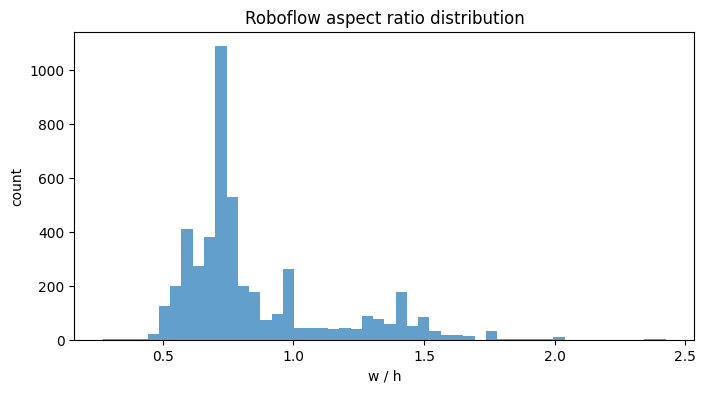

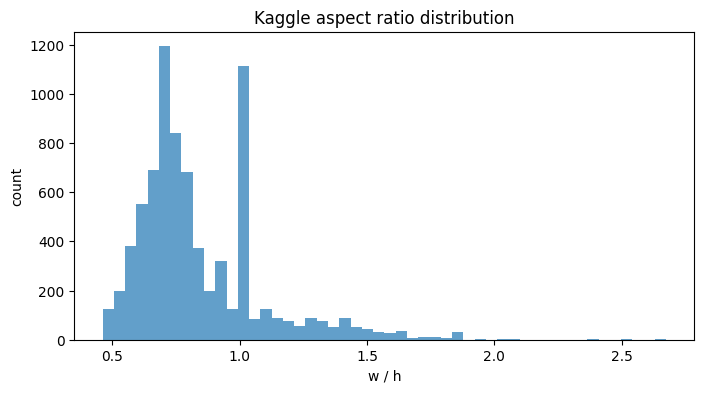

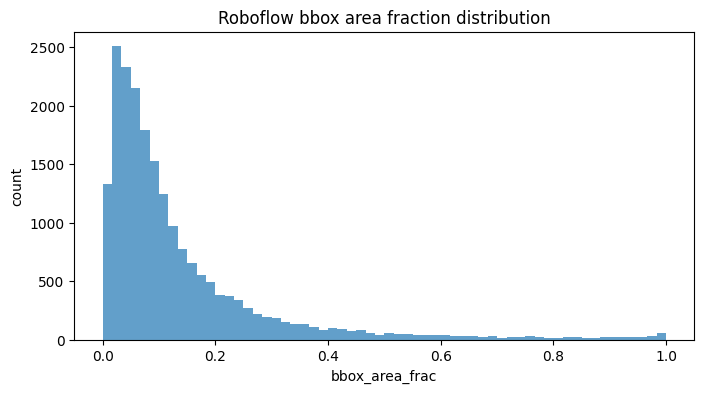

In [6]:

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(images_rf.loc[images_rf["ok"] == 1, "aspect_ratio"].dropna(), bins=50, alpha=0.7)
ax.set_title("Roboflow aspect ratio distribution")
ax.set_xlabel("w / h")
ax.set_ylabel("count")
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(images_kg.loc[images_kg["ok"] == 1, "aspect_ratio"].dropna(), bins=50, alpha=0.7)
ax.set_title("Kaggle aspect ratio distribution")
ax.set_xlabel("w / h")
ax.set_ylabel("count")
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(boxes_rf["bbox_area_frac"], bins=60, alpha=0.7)
ax.set_title("Roboflow bbox area fraction distribution")
ax.set_xlabel("bbox_area_frac")
ax.set_ylabel("count")
plt.show()


## 5. Audit of problem cases

Main problem groups:
- empty or missing labels;
- corrupted images;
- tiny or noise images;
- near-full boxes;
- exact duplicate hashes.


In [7]:

rf_empty = images_rf[(images_rf["label_bytes"].isna()) | (images_rf["label_bytes"] == 0)].copy()
kg_bad = images_kg[images_kg["ok"] == 0].copy()

near_full = boxes_rf[(boxes_rf["class_name"] == "menu-text") & (boxes_rf["bbox_area_frac"] >= 0.95)].copy()

rf_dups = (
    images_rf[images_rf["dhash"].notna()]
    .groupby("dhash")
    .agg(n=("image_path", "count"),
         splits=("split", lambda s: sorted(set(s))),
         images=("image_path", lambda s: list(s)[:10]))
    .reset_index()
)
rf_dups = rf_dups[rf_dups["n"] > 1].sort_values("n", ascending=False)

print("empty_or_missing_labels:", len(rf_empty))
print("corrupted_kaggle_images:", len(kg_bad))
print("near_full_boxes:", len(near_full))
print("exact_duplicate_hash_groups_in_roboflow:", len(rf_dups))

display(rf_empty.head(10))
display(kg_bad.head(10))
display(near_full.head(10))
display(rf_dups.head(10))


empty_or_missing_labels: 34
corrupted_kaggle_images: 1
near_full_boxes: 114
exact_duplicate_hash_groups_in_roboflow: 215


,source,split,image_path,label_path,img_w,img_h,image_bytes,label_bytes,ok,error_type,is_tiny,dhash,aspect_ratio,img_area
60,roboflow,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,data/raw/roboflow_menu_text_box_v3/Menu Text B...,75,75,1425,0,1,,1,80c0e8e0e8e808c0,1.000000,5625
61,roboflow,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,data/raw/roboflow_menu_text_box_v3/Menu Text B...,75,75,1112,0,1,,1,0000686868680000,1.000000,5625
62,roboflow,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,data/raw/roboflow_menu_text_box_v3/Menu Text B...,75,75,1395,0,1,,1,8080e8e0e8e828c0,1.000000,5625
936,roboflow,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,data/raw/roboflow_menu_text_box_v3/Menu Text B...,564,364,55918,0,1,,0,a26ae5ec62c8a4f8,1.549451,205296
937,roboflow,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,data/raw/roboflow_menu_text_box_v3/Menu Text B...,564,364,58916,0,1,,0,2660656c62eca5a8,1.549451,205296
938,roboflow,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,data/raw/roboflow_menu_text_box_v3/Menu Text B...,564,364,73237,0,1,,0,266c6d6c62eca5ec,1.549451,205296
1416,roboflow,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,data/raw/roboflow_menu_text_box_v3/Menu Text B...,563,784,58589,0,1,,0,f4e4f0f4e4e4c4ec,0.718112,441392
1417,roboflow,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,data/raw/roboflow_menu_text_box_v3/Menu Text B...,563,784,57241,0,1,,0,e0f4d2d4e4e4eccc,0.718112,441392
1418,roboflow,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,data/raw/roboflow_menu_text_box_v3/Menu Text B...,563,784,63679,0,1,,0,f4f4f0f4e4e4e4cd,0.718112,441392
2058,roboflow,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,data/raw/roboflow_menu_text_box_v3/Menu Text B...,235,180,10765,0,1,,0,a4a42ca2a6a6b6a0,1.305556,42300


,source,split,image_path,label_path,img_w,img_h,image_bytes,label_bytes,ok,error_type,is_tiny,dhash,aspect_ratio,img_area
6818,kaggle,all,data/raw/kaggle_indian_menu_cards/7136.jpg,None,NaN,NaN,0,None,0,UnidentifiedImageError,0,None,NaN,NaN


,split,image_path,class_id,class_name,xc,yc,bw,bh,annotation_source,bbox_area_frac
2196,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,0,menu-text,0.500000,0.503571,1.000000,0.992857,yolo,0.992857
2197,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,0,menu-text,0.500000,0.507143,1.000000,0.985714,yolo,0.985714
2274,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,0,menu-text,0.503846,0.497627,0.986154,0.995253,yolo,0.981473
2275,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,0,menu-text,0.504615,0.496044,0.970769,0.982595,yolo,0.953873
2574,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,0,menu-text,0.499006,0.508571,0.998012,0.957143,yolo,0.955240
2595,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,0,menu-text,0.500000,0.500000,1.000000,1.000000,yolo,1.000000
2596,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,0,menu-text,0.500000,0.500000,1.000000,1.000000,yolo,1.000000
3898,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,0,menu-text,0.500000,0.515375,1.000000,0.969250,yolo,0.969250
3899,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,0,menu-text,0.496454,0.515375,0.992908,0.956950,yolo,0.950163
3900,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,0,menu-text,0.500000,0.512300,1.000000,0.975400,yolo,0.975400


,dhash,n,splits,images
1398,6969696969696969,9,"[test, train, valid]",[data/raw/roboflow_menu_text_box_v3/Menu Text ...
2581,a4d4dac23cb798e4,5,"[train, valid]",[data/raw/roboflow_menu_text_box_v3/Menu Text ...
3316,cccccccccccccccc,4,"[train, valid]",[data/raw/roboflow_menu_text_box_v3/Menu Text ...
1415,696d6d6d6d6d6d6d,3,[train],[data/raw/roboflow_menu_text_box_v3/Menu Text ...
307,1717171717171717,3,[train],[data/raw/roboflow_menu_text_box_v3/Menu Text ...
2523,a0a2acacacaca9ac,3,[train],[data/raw/roboflow_menu_text_box_v3/Menu Text ...
3380,ce8c8e8e8e8cc4e0,3,[train],[data/raw/roboflow_menu_text_box_v3/Menu Text ...
1167,5f4f4d4b4b5b1d1d,3,[train],[data/raw/roboflow_menu_text_box_v3/Menu Text ...
3440,d0c1c1c1c1c1c1e1,3,[train],[data/raw/roboflow_menu_text_box_v3/Menu Text ...
2358,96d2d2f0f0f0c8d0,3,[train],[data/raw/roboflow_menu_text_box_v3/Menu Text ...


### How to read the duplicate audit

`dhash` is a simple near-duplicate signal.
If the same hash appears in different splits, we should check possible leakage by hand.
If duplicates come from data augmentation, this should be written clearly in the report.


In [8]:
boxes_with_size = boxes_rf.merge(
    images_rf[['split', 'image_path', 'img_w', 'img_h']],
    on=['split', 'image_path'],
    how='left',
)
boxes_with_size['bbox_w_px'] = boxes_with_size['bw'] * boxes_with_size['img_w']
boxes_with_size['bbox_h_px'] = boxes_with_size['bh'] * boxes_with_size['img_h']

display(
    boxes_with_size.groupby('class_name').agg(
        n=('class_name', 'count'),
        mean_area_frac=('bbox_area_frac', 'mean'),
        median_area_frac=('bbox_area_frac', 'median'),
        p95_area_frac=('bbox_area_frac', lambda s: float(np.percentile(s, 95))),
        mean_w_px=('bbox_w_px', 'mean'),
        mean_h_px=('bbox_h_px', 'mean'),
    )
)


,n,mean_area_frac,median_area_frac,p95_area_frac,mean_w_px,mean_h_px
class_name,,,,,,
menu-text,19409,0.141023,0.087169,0.469877,297.173046,215.988146
res_name,808,0.035575,0.027206,0.084616,212.967463,72.704901


## 6. Cleaning rules and final dataset version

### Cleaning policy
1. Remove tiny or noise images from supervised training.
2. Move empty or missing labels to quarantine.
3. Move corrupted files to quarantine.
4. Keep near-full boxes in a separate file for manual review.
5. Do not use the Kaggle corpus as supervised ground truth.


In [9]:
rf_supervised = images_rf[
    (images_rf['ok'] == 1)
    & (images_rf['is_tiny'] == 0)
    & (images_rf['label_bytes'].notna())
    & (images_rf['label_bytes'] > 0)
].copy()

boxes_supervised = boxes_rf.merge(
    rf_supervised[['split', 'image_path']],
    on=['split', 'image_path'],
    how='inner',
)

summary = {
    'roboflow': {
        'n_images_total': int(len(images_rf)),
        'n_images_supervised': int(len(rf_supervised)),
        'n_boxes_supervised': int(len(boxes_supervised)),
        'n_empty_or_missing_labels': int(len(rf_empty)),
        'n_tiny_images': int(images_rf['is_tiny'].sum()),
        'n_near_full_boxes': int(len(near_full)),
        'class_counts_supervised': boxes_supervised['class_name'].value_counts().to_dict(),
    },
    'kaggle': {
        'n_images_total': int(len(images_kg)),
        'n_valid_images': int((images_kg['ok'] == 1).sum()),
        'n_corrupted_images': int((images_kg['ok'] == 0).sum()),
        'n_tiny_images': int(images_kg['is_tiny'].sum()),
    },
    'final_decision': {
        'cv_main_dataset': 'roboflow_menu_text_box_v3',
        'ocr_domain_corpus': 'kaggle_indian_menu_cards',
        'nutrition_kb': 'usda_fooddata_central',
        'extra_food_source': 'open_food_facts',
        'main_pipeline': 'ocr_to_parsing_to_embeddings_rules_to_optional_llm_repair',
    },
}

summary


{'roboflow': {'n_images_total': 4757,
  'n_images_supervised': 4720,
  'n_boxes_supervised': 20214,
  'n_empty_or_missing_labels': 34,
  'n_tiny_images': 7,
  'n_near_full_boxes': 114,
  'class_counts_supervised': {'menu-text': 19406, 'res_name': 808}},
 'kaggle': {'n_images_total': 7790,
  'n_valid_images': 7789,
  'n_corrupted_images': 1,
  'n_tiny_images': 1},
 'final_decision': {'cv_main_dataset': 'roboflow_menu_text_box_v3',
  'ocr_domain_corpus': 'kaggle_indian_menu_cards',
  'nutrition_kb': 'usda_fooddata_central',
  'extra_food_source': 'open_food_facts',
  'main_pipeline': 'ocr_to_parsing_to_embeddings_rules_to_optional_llm_repair'}}

## 7. Save the checkpoint artifacts


In [ ]:

images_rf.to_csv(interim_root / "roboflow_manifest.csv", index=False)
boxes_rf.to_csv(interim_root / "roboflow_boxes.csv", index=False)
images_kg.to_csv(interim_root / "kaggle_manifest.csv", index=False)

rf_empty.to_csv(interim_root / "quarantine_empty_labels.csv", index=False)
kg_bad.to_csv(interim_root / "quarantine_corrupted_images.csv", index=False)
near_full.to_csv(interim_root / "quarantine_near_full_boxes.csv", index=False)

(interim_root / "dataset_summary.json").write_text(
    json.dumps(summary, ensure_ascii=False, indent=2),
    encoding="utf-8",
)


In [11]:
# Extra check before final conclusions

empty_not_tiny = rf_empty[rf_empty["is_tiny"] == 0].copy()
cross_split_dups = rf_dups[rf_dups["splits"].apply(len) > 1].copy()

tiny_and_empty = images_rf[
    (images_rf["is_tiny"] == 1)
    & ((images_rf["label_bytes"].isna()) | (images_rf["label_bytes"] == 0))
].copy()

print("empty_not_tiny:", len(empty_not_tiny))
print("cross_split_same_dhash_groups:", len(cross_split_dups))
print("tiny_and_empty_overlap:", len(tiny_and_empty))

display(empty_not_tiny[["split", "image_path", "img_w", "img_h", "label_bytes"]].head(20))
display(cross_split_dups.head(20))

empty_not_tiny: 30
cross_split_same_dhash_groups: 13
tiny_and_empty_overlap: 4


,split,image_path,img_w,img_h,label_bytes
936,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,564,364,0
937,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,564,364,0
938,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,564,364,0
1416,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,563,784,0
1417,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,563,784,0
1418,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,563,784,0
2058,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,235,180,0
2059,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,235,180,0
2060,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,235,180,0
2775,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,564,846,0


,dhash,n,splits,images
1398,6969696969696969,9,"[test, train, valid]",[data/raw/roboflow_menu_text_box_v3/Menu Text ...
2581,a4d4dac23cb798e4,5,"[train, valid]",[data/raw/roboflow_menu_text_box_v3/Menu Text ...
3316,cccccccccccccccc,4,"[train, valid]",[data/raw/roboflow_menu_text_box_v3/Menu Text ...
123,0c0cac8ecce42c8c,3,"[test, train]",[data/raw/roboflow_menu_text_box_v3/Menu Text ...
4306,f5e4e4e4e0c2e223,3,"[train, valid]",[data/raw/roboflow_menu_text_box_v3/Menu Text ...
2887,b6b4f4f4f4b6d2d2,2,"[test, train]",[data/raw/roboflow_menu_text_box_v3/Menu Text ...
2562,a3cececbeaccccce,2,"[test, train]",[data/raw/roboflow_menu_text_box_v3/Menu Text ...
3577,d9d999af9b9c9c9d,2,"[test, valid]",[data/raw/roboflow_menu_text_box_v3/Menu Text ...
911,47474e5e5e4f4d6d,2,"[test, train]",[data/raw/roboflow_menu_text_box_v3/Menu Text ...
362,1b13a72c1bcb8c8c,2,"[train, valid]",[data/raw/roboflow_menu_text_box_v3/Menu Text ...


## 8. Conclusions

### Final data decision
- **Roboflow Menu Text Box v3** is the main annotated dataset for the CV and layout part of the project.
- **Kaggle Indian Restaurant Menu Card Images** is an auxiliary raw menu corpus for OCR checks, robustness analysis, and manual gold-set annotation.
- **USDA FoodData Central** is the main nutrition knowledge base.
- **Open Food Facts** is used as an additional source for normalization and weak supervision.

### Main EDA findings
- The Roboflow dataset contains **4,757** images and **20,217** annotated boxes.
- After the current filtering step, the working supervised subset contains **4,720** images and **20,214** boxes.
- The dataset contains **34** images with empty or missing labels, **7** tiny images, and **114** near-full `menu-text` boxes.
- The Kaggle corpus contains **7,790** images, including **1** corrupted file.
- The class distribution is imbalanced: `menu-text` is the dominant class, while `res_name` is much smaller.

### Important quality notes
- Empty label files should not be treated as automatic errors. Some of them may be valid negative examples for detection and should be reviewed separately.
- Near-full boxes are not automatic annotation mistakes. Some of them may describe full menu regions and should be kept in a separate review list.
- The duplicate audit found repeated `dhash` groups, including some groups that appear in different splits. This is a leakage risk and should be checked manually before final training.

### Final cleaning policy
- Remove corrupted files and tiny noise images from training.
- Keep a separate review list for empty-label images.
- Keep near-full boxes in a manual review file.
- Use Kaggle only as an auxiliary domain corpus, not as supervised ground truth.

### Modeling decision
The main baseline path for the project is:

**OCR -> structured parsing -> embeddings + rules -> optional LLM repair/explanation**

This decision is better aligned with the available data than a full-image end-to-end VLM baseline. The current annotated data supports layout and detection tasks well, while downstream menu parsing still needs a small manually annotated gold set.

### Next step
1. Build a small gold set for `dish_name`, `price`, `section`, and `description`.
2. Train a detection baseline for the CV stage.
3. Evaluate a simple heuristic parser on the gold set.
4. Add an LLM repair step and compare it with the heuristic baseline.

In [2]:
import pandas as pd

for split in ["valid", "test"]:
    path = f"../reports/parser_baseline/parser_errors_{split}.csv"
    df = pd.read_csv(path)

    print("\nSPLIT:", split)
    print(df["error_type"].value_counts())


SPLIT: valid
error_type
missed_gold_item       151
false_positive_item     81
empty_pred_name         68
wrong_section           61
wrong_price             32
wrong_description        7
Name: count, dtype: int64

SPLIT: test
error_type
missed_gold_item       147
false_positive_item    124
empty_pred_name         50
wrong_price             46
wrong_section           35
wrong_description       11
Name: count, dtype: int64


In [3]:
import pandas as pd

df = pd.read_csv("../reports/parser_baseline/parser_errors_test.csv")

for error_type in ["wrong_section", "wrong_price", "wrong_description", "missed_gold_item"]:
    print("\nERROR TYPE:", error_type)
    display(df[df["error_type"] == error_type].head(20))


ERROR TYPE: wrong_section


,menu_id,page_id,error_type,pred_name,gold_name
1,batch_001_005,p1,wrong_section,GOLD LABEL,Gold Label
3,batch_001_005,p1,wrong_section,BLACK LABEL,Black Label
4,batch_001_005,p1,wrong_section,Chivas Regal,Chivas Regal
5,batch_001_005,p1,wrong_section,JAMESON Irish,Jameson Irish
8,batch_001_005,p1,wrong_section,TeacHERS Origin,Teachers Origin
9,batch_001_005,p1,wrong_section,BLACK Dog,Black Dog
10,batch_001_005,p1,wrong_section,Dewars White LABEL,Dewars White Label
12,batch_001_005,p1,wrong_section,CANADIAN CLub,Canadian Club
18,batch_001_005,p1,wrong_section,GLEnfIdDich SINGle MALTS,Glenfiddich Single Malts
19,batch_001_005,p1,wrong_section,The GLEN LiveT,The Glen Livet



ERROR TYPE: wrong_price


,menu_id,page_id,error_type,pred_name,gold_name
2,batch_001_005,p1,wrong_price,GOLD LABEL,Gold Label
41,batch_001_007,p1,wrong_price,BacaRDI ApPLe,Bacardi Apple
52,batch_001_007,p1,wrong_price,Fosters,Fosters
119,batch_002_012,p1,wrong_price,Patta Gobi (Gujarati),Patta Gobi (Gujarati)
120,batch_002_012,p1,wrong_price,Aloo Patta Gobi,Aloo Patta Gobi
122,batch_002_012,p1,wrong_price,Dum Aloo,Dum Aloo
123,batch_002_012,p1,wrong_price,Aloo Curry,Aloo Curry
124,batch_002_012,p1,wrong_price,Aloo Tomato Shimla,Aloo Tomato Shimla
125,batch_002_012,p1,wrong_price,Aloo Shimla,Aloo Shimla
126,batch_002_012,p1,wrong_price,Aloo Methi,Aloo Methi



ERROR TYPE: wrong_description


,menu_id,page_id,error_type,pred_name,gold_name
223,batch_003_001,p1,wrong_description,Fruit Mix Confusions,Fruit Mix Confusions
231,batch_003_001,p1,wrong_description,Butterscotch Kick,Butterscotch Kick
239,batch_003_001,p1,wrong_description,Caramel Nuts,Caramel Nuts
242,batch_003_001,p1,wrong_description,Black Forest Ecstasy,Black Forest Ecstasy
247,batch_003_001,p1,wrong_description,Ferrero Nutella,Ferrero Nutella
254,batch_003_001,p1,wrong_description,Fruit & Nut,Fruit & Nut
274,batch_003_004,p1,wrong_description,Mocha Frappe,Mocha Frappe
280,batch_003_004,p1,wrong_description,Rose Falooda,Rose Falooda
283,batch_003_004,p1,wrong_description,Oreo Shake,Oreo Shake
288,batch_003_004,p1,wrong_description,Mango Madness,Mango Madness



ERROR TYPE: missed_gold_item


,menu_id,page_id,error_type,pred_name,gold_name
25,batch_001_005,p1,missed_gold_item,NaN,J.W. Red Label
26,batch_001_005,p1,missed_gold_item,NaN,Teacher 50
27,batch_001_005,p1,missed_gold_item,NaN,Ballentine's
28,batch_001_005,p1,missed_gold_item,NaN,100 Pipers
29,batch_001_005,p1,missed_gold_item,NaN,Teachers Highland Cream
30,batch_001_005,p1,missed_gold_item,NaN,Black & White
31,batch_001_005,p1,missed_gold_item,NaN,Vat 69
32,batch_001_005,p1,missed_gold_item,NaN,Laphroaig
33,batch_001_005,p1,missed_gold_item,NaN,Jim Beam
34,batch_001_005,p1,missed_gold_item,NaN,Jack Daniels
